In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
nitikachandel95_student_social_media_impact_dataset_path = kagglehub.dataset_download('nitikachandel95/student-social-media-impact-dataset')

print('Data source import complete.')


C:\Users\jimmy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Global Student Digital Behaviour and Social Media Impact Analysis

This project analyzes the relationship between social media usage, digital behavior, and student outcomes such as academic performance, attention span, mental health, and spending behavior.

The dataset used in this notebook is a **synthetically generated dataset** designed to simulate realistic global digital behavior patterns among students aged 15–25.

The objective of this project is to explore how digital exposure may influence cognitive, academic, psychological, and economic outcomes.

In [3]:
import os
print(os.listdir(nitikachandel95_student_social_media_impact_dataset_path))

['global_student_digital_behavior_dataset.csv']


In [4]:
import os
print(os.listdir(nitikachandel95_student_social_media_impact_dataset_path))

['global_student_digital_behavior_dataset.csv']


In [5]:
import pandas as pd
import os

df = pd.read_csv(
    os.path.join(nitikachandel95_student_social_media_impact_dataset_path, "global_student_digital_behavior_dataset.csv")
)

df.head()

,student_id,country,development_level,poverty_rate_percent,internet_infrastructure_index,average_internet_speed_mbps,age,gender,urban_rural,family_income_level,...,ads_viewed_per_day,ads_clicked_per_week,impulse_purchase_score,digital_spending_per_month,cyberbullying_exposure,adult_content_exposure,digital_addiction_score,wellbeing_index,academic_risk_score,financial_risk_score
0,1,Qatar,Developing,16.30,54.93,27.19,21,Male,Rural,High,...,38.699484,3.119569,3.681066,79.508194,No,No,8.179932,66.662166,0.0,26.516722
1,2,USA,Developed,8.75,94.39,85.34,25,Male,Urban,Middle,...,157.400429,18.358090,6.538867,73.452464,No,Yes,22.073122,43.892278,0.0,39.257741
2,3,Mexico,Developing,23.64,47.24,73.55,18,Female,Urban,Low,...,79.603536,11.758299,5.150660,35.753069,No,No,12.591830,65.484625,0.0,47.542155
3,4,Canada,Developed,14.51,90.50,188.19,25,Male,Urban,Middle,...,69.318324,7.906197,3.195383,47.607487,No,Yes,8.008238,57.909392,0.0,23.436122
4,5,Sri Lanka,Underdeveloped,62.28,36.84,11.02,15,Other,Rural,Middle,...,144.019899,19.427839,7.180234,82.941313,No,No,21.551334,53.686356,0.0,47.308493


## 1. Import Required Libraries

We begin by importing the necessary Python libraries for data analysis and visualization.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

The dataset contains simulated student digital behavior data across multiple countries.

Each record represents one student and includes:

- demographic attributes
- socioeconomic context
- internet access and device usage
- social media behavior
- academic indicators
- psychological outcomes
- financial behavior

In [ ]:
import os
import pandas as pd

kaggle_csv = "/kaggle/input/student-social-media-impact-dataset/global_student_digital_behavior_dataset.csv"
local_candidates = [
    os.path.join("dataset", "global_student_digital_behavior_dataset (1).csv"),
    os.path.join("dataset", "global_student_digital_behavior_dataset.csv"),
]
if "nitikachandel95_student_social_media_impact_dataset_path" in globals():
    local_candidates.insert(
        0,
        os.path.join(
            nitikachandel95_student_social_media_impact_dataset_path,
            "global_student_digital_behavior_dataset.csv",
        ),
    )

csv_path = next(
    (path for path in [kaggle_csv, *local_candidates] if os.path.exists(path)),
    None,
)
if csv_path is None:
    import kagglehub
    dataset_dir = kagglehub.dataset_download(
        "nitikachandel95/student-social-media-impact-dataset"
    )
    csv_path = os.path.join(dataset_dir, "global_student_digital_behavior_dataset.csv")

print("Loading:", csv_path)
students = pd.read_csv(csv_path)
students.head()

## 3. Dataset Overview

Before analysis, we inspect the dataset structure and variable types.

In [ ]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 48 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   student_id                      500000 non-null  int64  
 1   country                         500000 non-null  object 
 2   development_level               500000 non-null  object 
 3   poverty_rate_percent            500000 non-null  float64
 4   internet_infrastructure_index   500000 non-null  float64
 5   average_internet_speed_mbps     500000 non-null  float64
 6   age                             500000 non-null  int64  
 7   gender                          500000 non-null  object 
 8   urban_rural                     500000 non-null  object 
 9   family_income_level             500000 non-null  object 
 10  device_access                   500000 non-null  object 
 11  internet_access_hours           500000 non-null  float64
 12  education_level 

In [ ]:
students.describe()

,student_id,poverty_rate_percent,internet_infrastructure_index,average_internet_speed_mbps,age,internet_access_hours,academic_motivation,online_learning_hours,social_media_hours,sessions_per_day,...,anxiety_score,depression_score,ads_viewed_per_day,ads_clicked_per_week,impulse_purchase_score,digital_spending_per_month,digital_addiction_score,wellbeing_index,academic_risk_score,financial_risk_score
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,...,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,250000.500000,26.157521,60.211633,72.663154,19.996474,5.013043,5.390749,6.318560,3.360787,9.901511,...,4.861232,5.085747,97.020675,12.643289,5.483062,59.888421,14.074256,57.259265,0.110863,41.659380
std,144337.711635,15.246496,20.732890,65.315300,3.161021,1.581660,1.741491,1.848903,1.292885,3.382135,...,1.771165,2.073001,33.335935,4.469668,1.578085,29.120812,5.916848,10.568436,0.796290,13.584693
min,1.000000,5.210000,20.760000,5.740000,15.000000,0.500000,1.000000,0.000000,0.000000,1.000000,...,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,13.755421,0.000000,0.000000
25%,125000.750000,13.660000,43.130000,20.420000,17.000000,3.911805,4.238213,5.080963,2.457786,7.547886,...,3.628933,3.612049,73.817802,9.557982,4.398106,38.202779,9.906583,50.058289,0.000000,32.211889
50%,250000.500000,22.330000,55.750000,45.630000,20.000000,5.012280,5.457743,6.354281,3.290051,9.744129,...,4.837090,5.044635,95.385942,12.492320,5.446927,55.094270,13.608465,57.444352,0.000000,41.019862
75%,375000.250000,37.930000,78.920000,107.410000,23.000000,6.112144,6.611136,7.585492,4.196469,12.097976,...,6.063411,6.512151,118.644706,15.577609,6.539470,76.732047,18.043002,64.640520,0.000000,50.493556
max,500000.000000,62.280000,94.390000,238.050000,25.000000,11.273316,10.000000,13.530034,9.000000,26.032059,...,10.000000,10.000000,256.626877,33.933309,10.000000,198.609505,40.222905,99.385461,24.070404,100.000000


## 4. Social Media Usage Distribution

Understanding how much time students spend on social media is critical to interpreting digital behavior patterns.

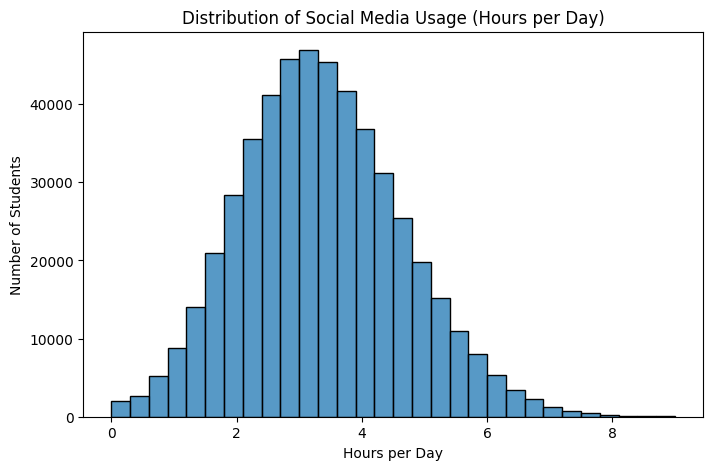

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(students["social_media_hours"], bins=30)
plt.title("Distribution of Social Media Usage (Hours per Day)")
plt.xlabel("Hours per Day")
plt.ylabel("Number of Students")
plt.show()

## 5. Brain Rot Index

The Brain Rot Index represents digital overstimulation caused by high short-video consumption, frequent sessions, and late-night usage.

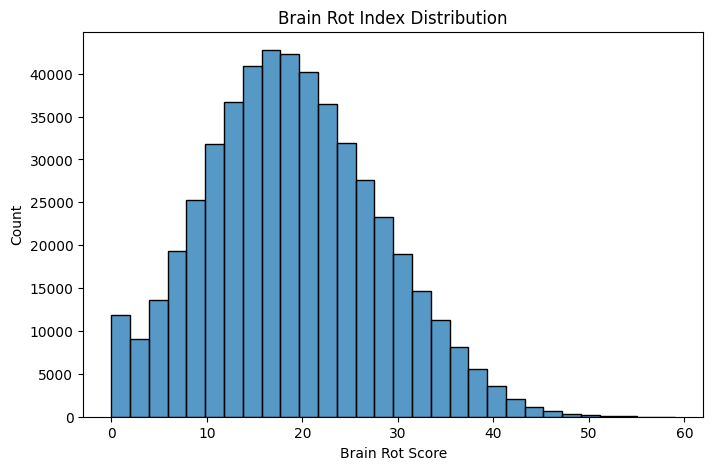

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(students["brain_rot_index"], bins=30)
plt.title("Brain Rot Index Distribution")
plt.xlabel("Brain Rot Score")
plt.show()

Higher education levels show slightly reduced casual social media usage.

<Axes: xlabel='education_level'>

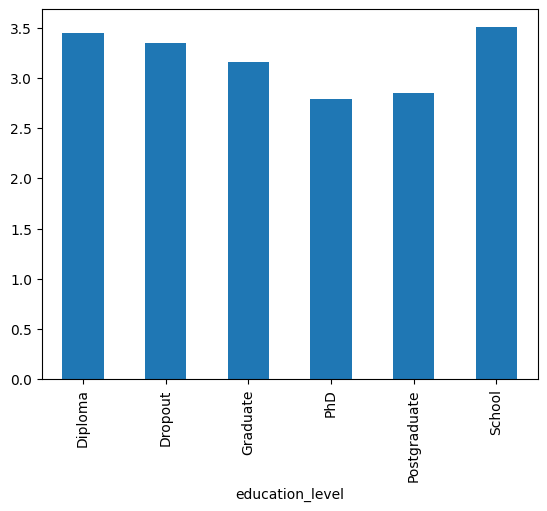

In [ ]:
df.groupby("education_level")["social_media_hours"].mean().plot(kind="bar")

## 6. Social Media Usage vs Attention Span

We examine whether higher social media usage is associated with shorter attention spans.

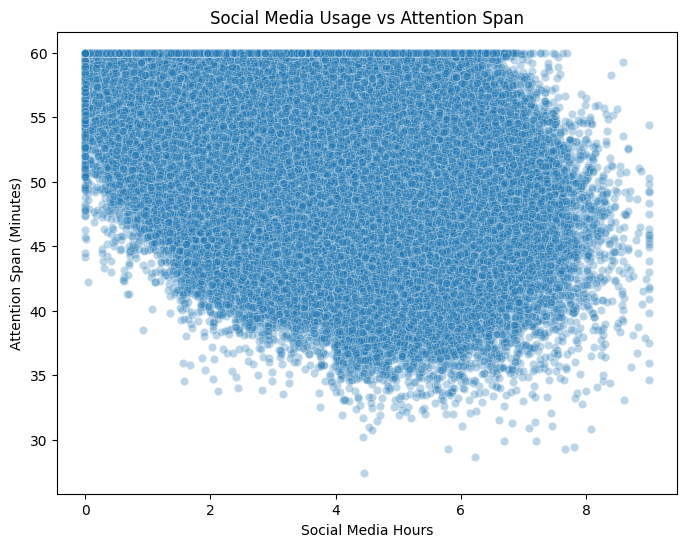

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="social_media_hours",
    y="attention_span_minutes",
    data=students,
    alpha=0.3
)
plt.title("Social Media Usage vs Attention Span")
plt.xlabel("Social Media Hours")
plt.ylabel("Attention Span (Minutes)")
plt.show()

## 7. Social Media Usage Groups

Students are categorized into three usage groups:

- Low Usage
- Moderate Usage
- High Usage

This helps compare behavioral outcomes across groups.

In [ ]:
students["usage_group"] = pd.cut(
    students["social_media_hours"],
    bins=[0,2,5,10],
    labels=["Low","Moderate","High"]
)

students.groupby("usage_group")[[
    "attention_span_minutes",
    "study_hours_per_week",
    "stress_level",
    "productivity_score"
]].mean()

/tmp/ipykernel_22628/2162349368.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  students.groupby("usage_group")[[


,attention_span_minutes,study_hours_per_week,stress_level,productivity_score
usage_group,,,,
Low,56.528027,24.115367,3.538075,9.495075
Moderate,53.759772,23.018162,4.870945,8.857399
High,49.531558,21.233311,6.465379,7.720893


## 8. Attention Span Across Usage Groups

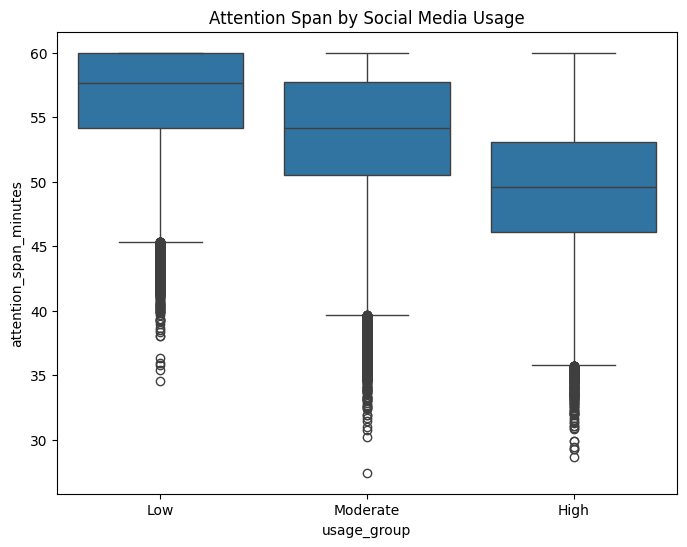

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x="usage_group",
    y="attention_span_minutes",
    data=students
)

plt.title("Attention Span by Social Media Usage")
plt.show()

## 9. Brain Rot vs Academic Behaviour

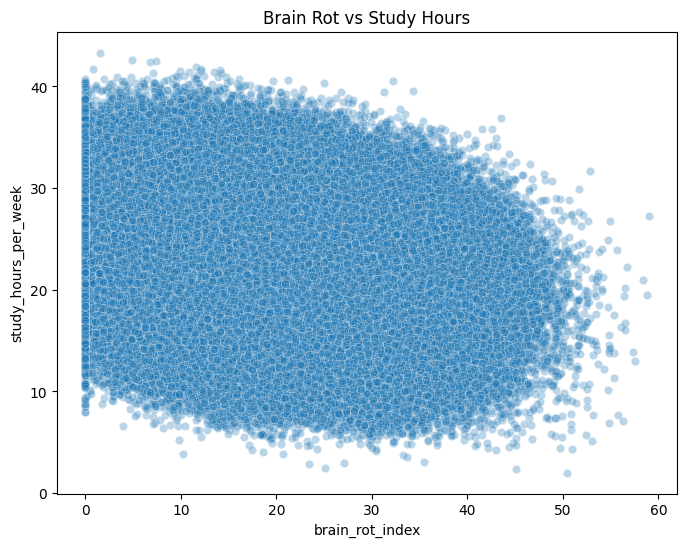

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="brain_rot_index",
    y="study_hours_per_week",
    data=students,
    alpha=0.3
)

plt.title("Brain Rot vs Study Hours")
plt.show()

## 10. Correlation Matrix

We examine the relationships between major numeric variables in the dataset.

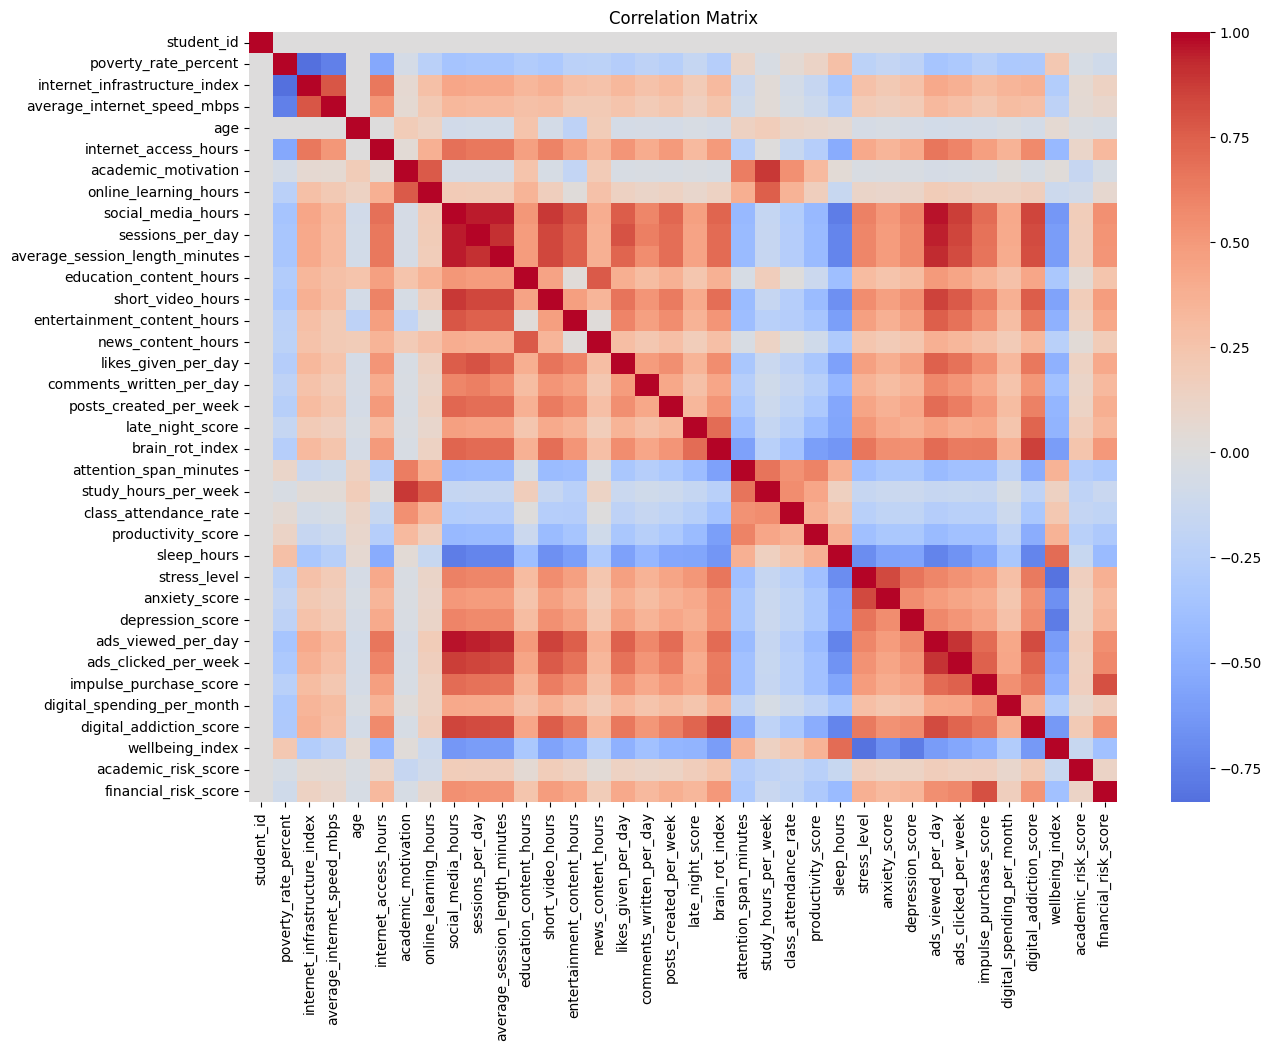

In [ ]:
numeric = students.select_dtypes(include=["float64","int64"])

plt.figure(figsize=(14,10))
sns.heatmap(numeric.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

## 11. Digital Spending Behaviour

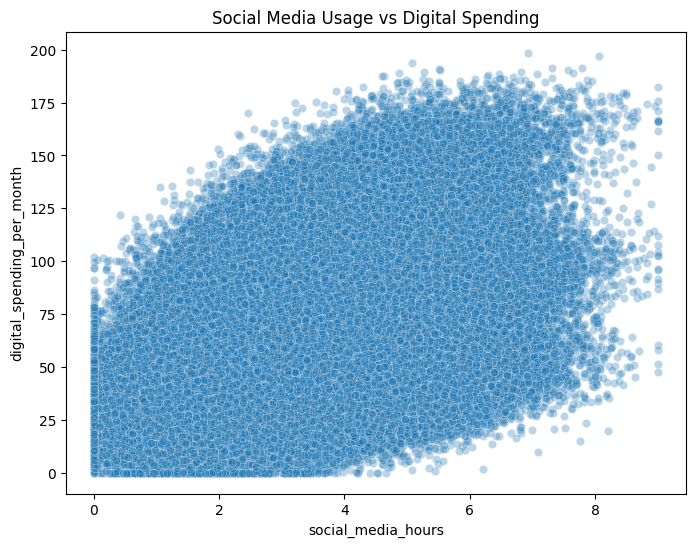

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="social_media_hours",
    y="digital_spending_per_month",
    data=students,
    alpha=0.3
)

plt.title("Social Media Usage vs Digital Spending")
plt.show()

## 12. Key Observations

Several patterns emerge from the dataset:

• Higher social media usage tends to correlate with lower attention spans.

• Students with higher Brain Rot Index scores tend to show reduced study hours.

• Late-night digital behavior appears associated with increased stress levels.

• Digital advertising exposure may influence impulse purchasing and spending behavior.

These findings illustrate potential links between digital consumption habits and student wellbeing outcomes.

## 13. Conclusion

This notebook demonstrates how synthetic behavioral datasets can be used to explore the potential impact of social media on student outcomes.

Although the dataset is simulated, the structural dependencies between variables allow meaningful exploratory analysis and can serve as a foundation for further research, modeling, and policy discussion.

## 14. Cross-Country Digital Behaviour Comparison

Digital behaviour and its outcomes may vary significantly across countries due to differences in socioeconomic conditions, internet infrastructure, and educational systems.

In this section, we compare average social media usage and attention span across countries.

In [ ]:
country_summary = students.groupby("country")[[
    "social_media_hours",
    "attention_span_minutes",
    "study_hours_per_week",
    "stress_level"
]].mean().sort_values(by="social_media_hours", ascending=False)

country_summary.head(10)

,social_media_hours,attention_span_minutes,study_hours_per_week,stress_level
country,,,,
USA,4.291741,52.499083,23.217016,5.476691
UK,4.260584,52.533129,23.250608,5.484478
Japan,4.254363,52.582940,23.292326,5.483212
Germany,4.226409,52.631870,23.215423,5.441586
Switzerland,4.205152,52.637813,23.270742,5.442922
Canada,4.170785,52.696128,23.226715,5.428073
France,4.071670,52.770572,23.231871,5.361677
Denmark,3.977874,53.042139,23.325193,5.297276
Singapore,3.938352,53.085790,23.259909,5.248038


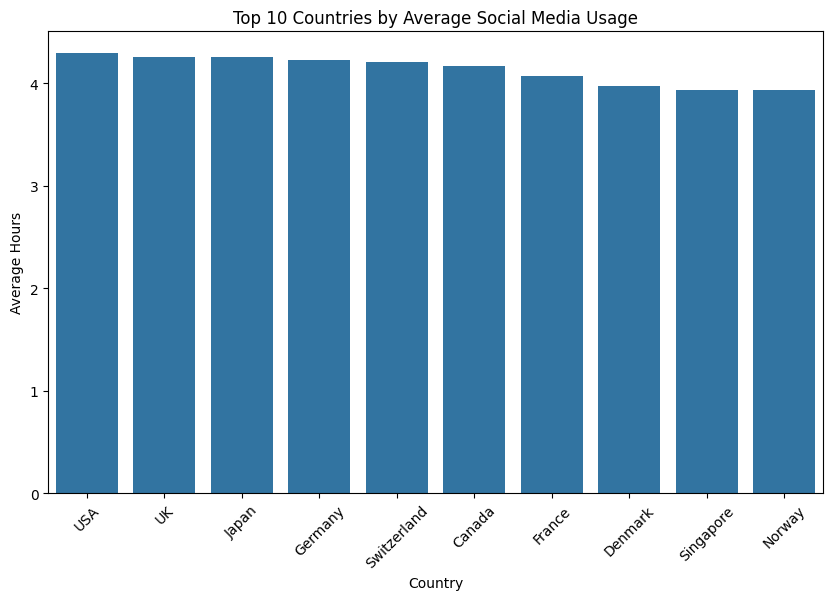

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=country_summary.head(10).index,
    y=country_summary.head(10)["social_media_hours"]
)
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Average Social Media Usage")
plt.ylabel("Average Hours")
plt.xlabel("Country")
plt.show()

## 15. Predicting Academic Risk

We attempt to predict the academic risk score based on digital behaviour features such as social media usage, brain rot index, attention span, and stress levels.

A simple regression model is used for demonstration.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

features = [
    "social_media_hours",
    "brain_rot_index",
    "attention_span_minutes",
    "stress_level",
    "sleep_hours"
]

X = students[features]
y = students["academic_risk_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, pred))

R² Score: 0.0846816349366094


The R² score provides a simple measure of how well digital behavior variables explain variations in academic risk.

## 16. Feature Importance

We examine which variables contribute most strongly to predicting academic risk.

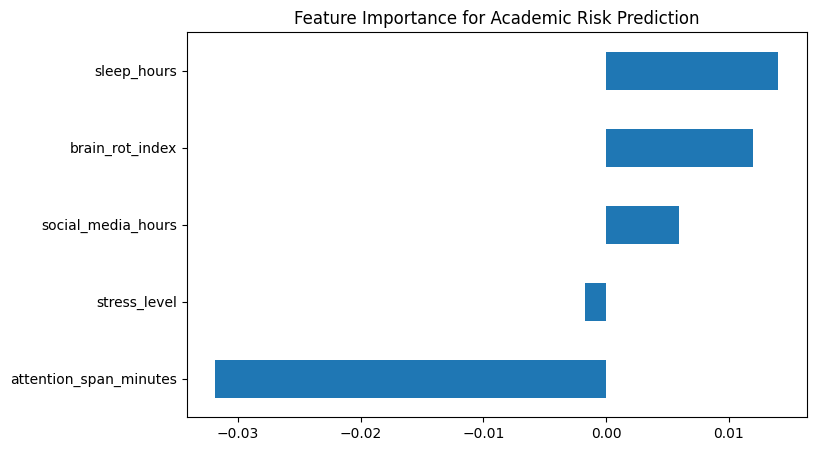

In [ ]:
importance = pd.Series(
    model.coef_,
    index=features
)

importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance for Academic Risk Prediction")
plt.show()

## 17. Clustering Student Digital Behaviour

To better understand digital habits, we group students into behavioral clusters based on:

- social media usage
- brain rot index
- attention span
- study hours

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
cluster_features = students[[
    "social_media_hours",
    "brain_rot_index",
    "attention_span_minutes",
    "study_hours_per_week"
]]

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_features)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
students["behavior_cluster"] = kmeans.fit_predict(scaled)

In [ ]:
students.groupby("behavior_cluster")[[
    "social_media_hours",
    "brain_rot_index",
    "attention_span_minutes",
    "study_hours_per_week"
]].mean()

,social_media_hours,brain_rot_index,attention_span_minutes,study_hours_per_week
behavior_cluster,,,,
0,4.037117,23.168857,54.796307,25.450289
1,4.168446,26.057334,47.738620,17.708834
2,2.336027,11.322064,57.034443,24.888244


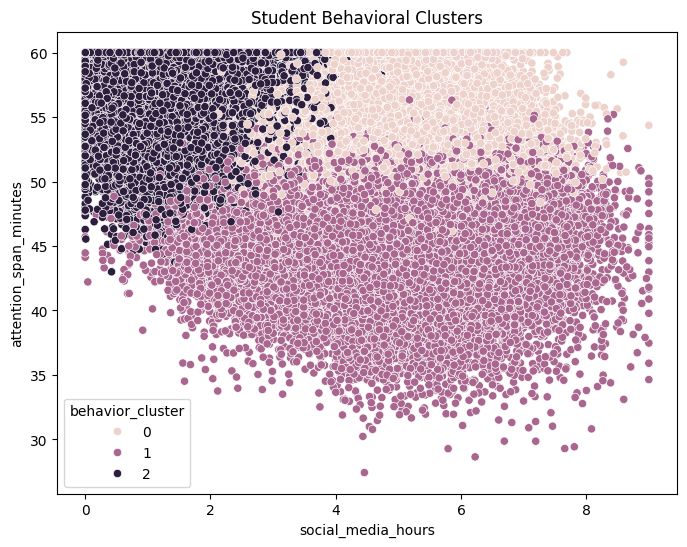

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=students,
    x="social_media_hours",
    y="attention_span_minutes",
    hue="behavior_cluster"
)

plt.title("Student Behavioral Clusters")
plt.show()

In [ ]:
cluster_summary = students.groupby("behavior_cluster")[[
    "social_media_hours",
    "brain_rot_index",
    "attention_span_minutes",
    "study_hours_per_week"
]].mean()

cluster_summary

,social_media_hours,brain_rot_index,attention_span_minutes,study_hours_per_week
behavior_cluster,,,,
0,4.037117,23.168857,54.796307,25.450289
1,4.168446,26.057334,47.738620,17.708834
2,2.336027,11.322064,57.034443,24.888244


In [ ]:
cluster_means = cluster_summary.copy()

labels = {}

for cluster in cluster_means.index:

    sm = cluster_means.loc[cluster, "social_media_hours"]
    brain = cluster_means.loc[cluster, "brain_rot_index"]
    attention = cluster_means.loc[cluster, "attention_span_minutes"]

    if brain > cluster_means["brain_rot_index"].mean() and attention < cluster_means["attention_span_minutes"].mean():
        labels[cluster] = "High Risk"

    elif sm < cluster_means["social_media_hours"].mean() and attention > cluster_means["attention_span_minutes"].mean():
        labels[cluster] = "Focused"

    else:
        labels[cluster] = "Balanced"

In [ ]:
students["behavior_label"] = students["behavior_cluster"].map(labels)

In [ ]:
students["behavior_label"].value_counts()

,count
behavior_label,
Focused,209922
Balanced,145926
High Risk,144152


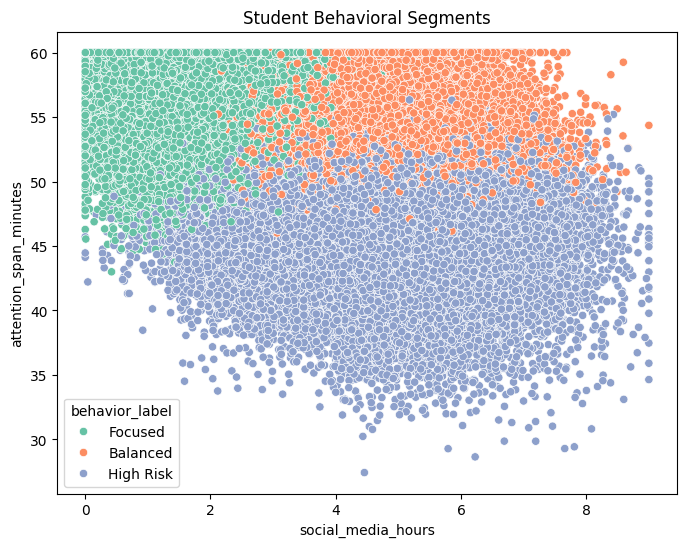

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=students,
    x="social_media_hours",
    y="attention_span_minutes",
    hue="behavior_label",
    palette="Set2"
)

plt.title("Student Behavioral Segments")
plt.show()

## 19. Cluster Interpretation

The clustering results typically reveal three behavioural profiles:

Cluster 0 — Low Usage Students  
Lower social media usage and higher attention spans.

Cluster 1 — Balanced Users  
Moderate digital activity with balanced academic outcomes.

Cluster 2 — Heavy Digital Users  
Higher brain rot index, reduced attention spans, and lower study hours.

These clusters illustrate how digital habits can shape different behavioral patterns among students.

## 20. Final Summary

This project constructed and analyzed a synthetic global dataset of student digital behavior.

Key insights include:

• Social media intensity correlates with reduced attention spans.  
• Heavy digital usage is associated with increased academic risk.  
• Digital exposure appears linked to psychological stress indicators.  
• Clustering reveals distinct behavioral profiles among students.

This project demonstrates how structured synthetic datasets can support exploratory research into the complex relationships between digital technology and student wellbeing.

### 21. LightGBM Implementation ###

In [ ]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 86.2 MB/s eta 0:00:00


In [ ]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Define features and target based on previous analysis
features = [
    "social_media_hours",
    "brain_rot_index",
    "attention_span_minutes",
    "stress_level",
    "sleep_hours"
]

X = students[features]
y = students["academic_risk_score"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train the LightGBM Regressor model
model_lgbm = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    colsample_bytree=0.8,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

print("Training LightGBM Regressor...")
model_lgbm.fit(X_train, y_train)

# Make predictions
y_pred_lgbm = model_lgbm.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred_lgbm)
r2 = r2_score(y_test, y_pred_lgbm)

print(f"\nLightGBM Mean Squared Error: {mse:.4f}")
print(f"LightGBM R² Score: {r2:.4f}")

Training LightGBM Regressor...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023479 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 400000, number of used features: 5
[LightGBM] [Info] Start training from score 0.111266

LightGBM Mean Squared Error: 0.4778
LightGBM R² Score: 0.2147


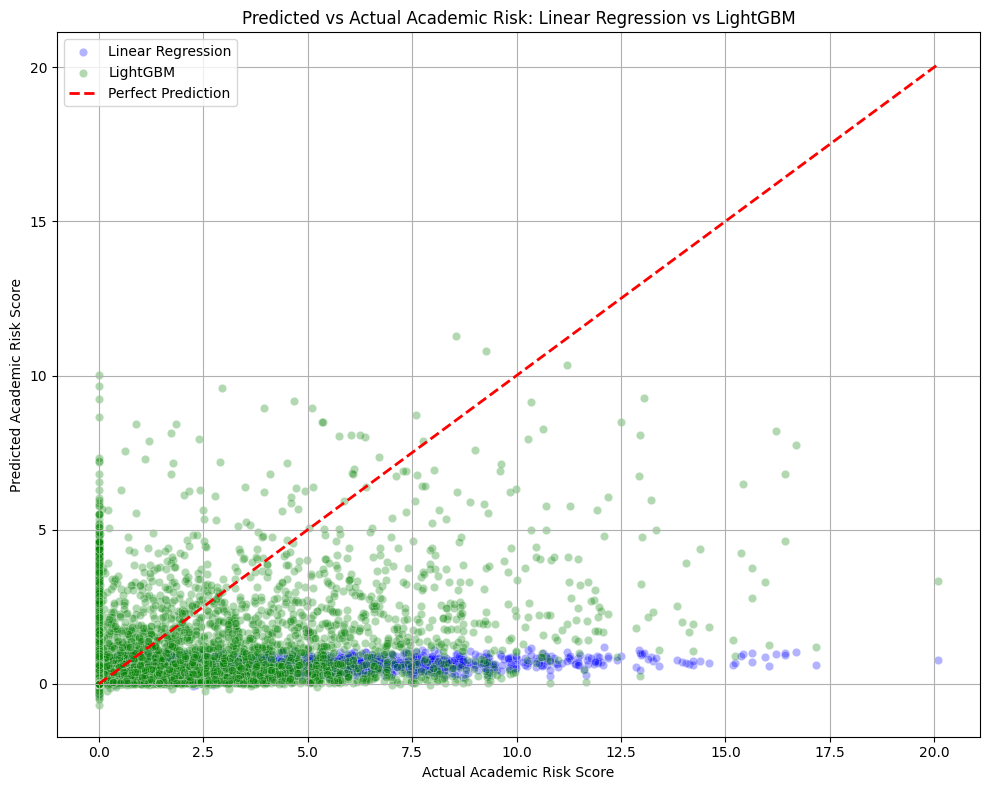

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Plotting Linear Regression predictions vs actuals
sns.scatterplot(x=y_test, y=pred, alpha=0.3, color='blue', label='Linear Regression')

# Plotting LightGBM predictions vs actuals
sns.scatterplot(x=y_test, y=y_pred_lgbm, alpha=0.3, color='green', label='LightGBM')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.title('Predicted vs Actual Academic Risk: Linear Regression vs LightGBM')
plt.xlabel('Actual Academic Risk Score')
plt.ylabel('Predicted Academic Risk Score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Residual Graphs

Residual plots help visualize the errors (residuals) of a regression model. Ideally, residuals should be randomly scattered around zero, indicating that the model captures the underlying patterns well and there are no systematic biases. We will plot the residuals against the predicted values for both models.

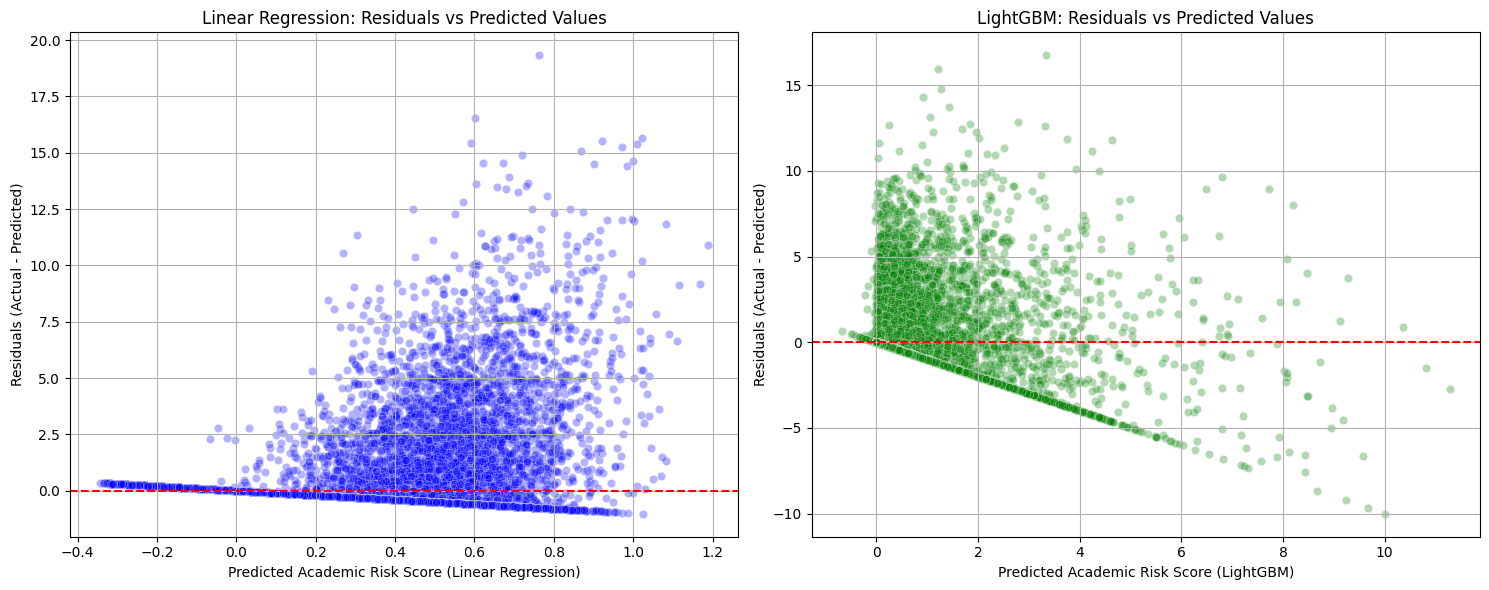

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for Linear Regression
residuals_lr = y_test - pred

# Calculate residuals for LightGBM
residuals_lgbm = y_test - y_pred_lgbm

plt.figure(figsize=(15, 6))

# Residual Plot for Linear Regression
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x=pred, y=residuals_lr, alpha=0.3, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Linear Regression: Residuals vs Predicted Values')
plt.xlabel('Predicted Academic Risk Score (Linear Regression)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)

# Residual Plot for LightGBM
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x=y_pred_lgbm, y=residuals_lgbm, alpha=0.3, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('LightGBM: Residuals vs Predicted Values')
plt.xlabel('Predicted Academic Risk Score (LightGBM)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)

plt.tight_layout()
plt.show()

#### Quantitative Model Accuracy Comparison

To further compare the accuracy, we can look at common regression metrics:

*   **Mean Absolute Error (MAE):** The average of the absolute differences between predictions and actual values. It's less sensitive to outliers than MSE.
*   **Root Mean Squared Error (RMSE):** The square root of the Mean Squared Error (MSE). It is in the same units as the target variable, making it more interpretable than MSE.
*   **R-squared (R²):** The proportion of variance in the dependent variable that can be predicted from the independent variables. A higher R² indicates a better fit.

We will calculate these for both Linear Regression and LightGBM.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("--- Linear Regression Metrics ---")
mae_lr = mean_absolute_error(y_test, pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred))
r2_lr = r2_score(y_test, pred) # Re-using previously calculated R2

print(f"MAE: {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R² Score: {r2_lr:.4f}")

print("\n--- LightGBM Metrics ---")
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm)) # Re-using previously calculated MSE to get RMSE
r2_lgbm = r2_score(y_test, y_pred_lgbm) # Re-using previously calculated R2

print(f"MAE: {mae_lgbm:.4f}")
print(f"RMSE: {rmse_lgbm:.4f}")
print(f"R² Score: {r2_lgbm:.4f}")

--- Linear Regression Metrics ---
MAE: 0.2795
RMSE: 0.7463
R² Score: 0.0847

--- LightGBM Metrics ---
MAE: 0.1592
RMSE: 0.6913
R² Score: 0.2147


### Summary Table of Model Performance Metrics

In [ ]:
import pandas as pd

metrics_data = {
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Linear Regression': [mae_lr, rmse_lr, r2_lr],
    'LightGBM': [mae_lgbm, rmse_lgbm, r2_lgbm]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df = metrics_df.set_index('Metric')

# Format the numbers for better readability
metrics_df = metrics_df.map(lambda x: f'{x:.4f}')

display(metrics_df)

,Linear Regression,LightGBM
Metric,,
MAE,0.2795,0.1592
RMSE,0.7463,0.6913
R² Score,0.0847,0.2147
